# Tester_branch에서 성능 확인 진행

In [ ]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

''' 데이터 코드를 작성해주세요 '''

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

# 데이터프레임 생성
df = pd.DataFrame(data=wine.data, columns = wine.feature_names)
df['target'] = wine.target

# feature와 target의 데이터 분리
X = df.drop('target', axis=1)
y = df['target']

# 학습데이터와 테스트 데이터로 분리(test size 0.2, random_state 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)


# DT 모델링 성능

Best Hyper-parmeter {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Score 0.9444444444444444


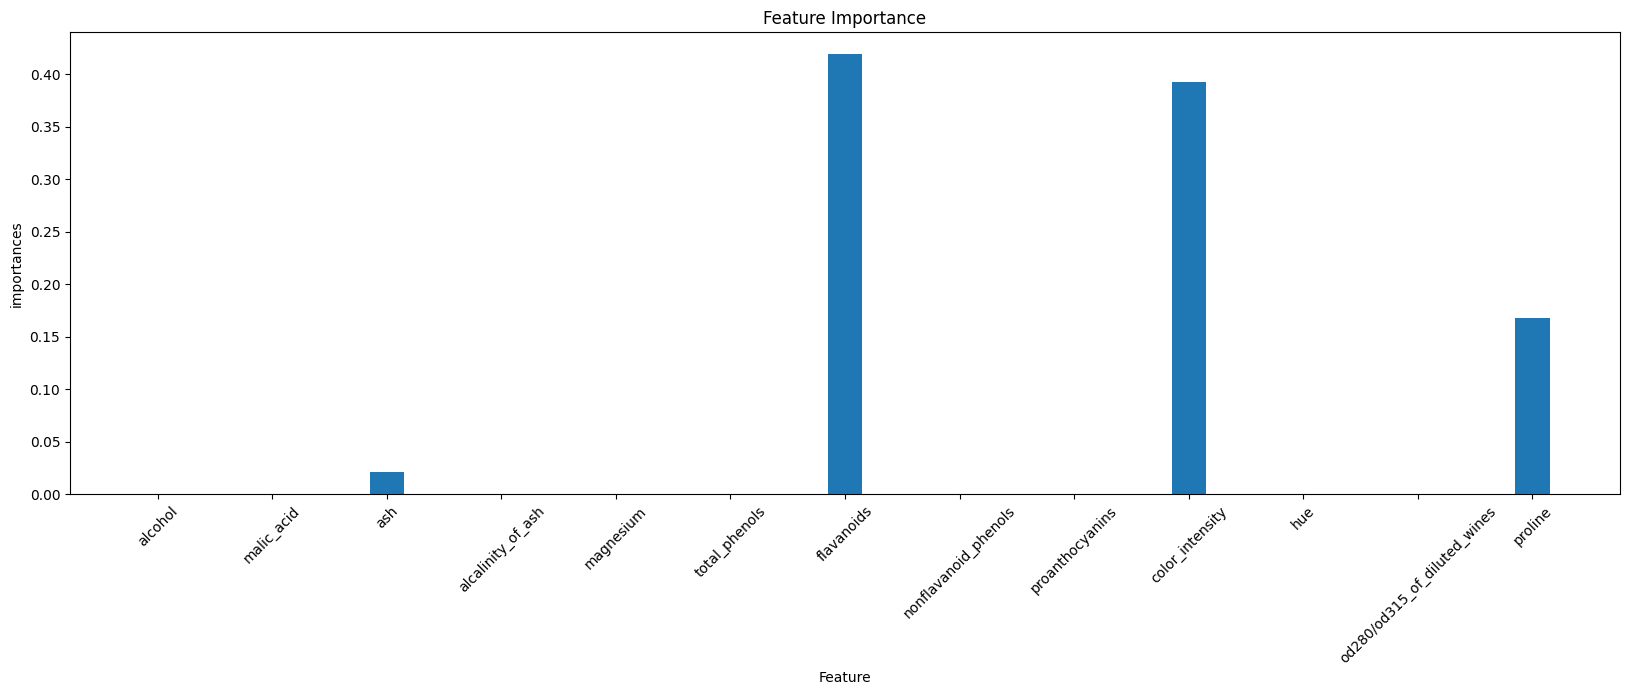

In [4]:
''' 코드를 작성해주세요 '''

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# GridSearch를 활용한 하이퍼파라미터 튜닝
param_grid = {
    "criterion" : ['gini', 'entropy'],
    "max_depth" : [2,5],
    "min_samples_split" : [2, 10],
    "min_samples_leaf" : [1, 2, 4]
}

# HPO
clf_grid = DecisionTreeClassifier(random_state=42)

# core
grid_search = GridSearchCV(clf_grid, param_grid, cv =5)

# 하이퍼파라미터를 찾고, fitting 수행
grid_search.fit(X_train,y_train)

# accuracy를 기준으로 모델 정확도 평가
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

y_pred_grid = best_model.predict(X_test)
accuracy_grid = accuracy_score(y_test, y_pred_grid)

# 특성 Importacne
importances = best_model.feature_importances_

print(f"Best Hyper-parmeter {best_params}")
print(f"Best Score {accuracy_grid}")

# Best model의 Feature Importance를  시각화
plt.figure(figsize = (20,6))

# 막대 그래프 생성
plt.bar(range(len(importances)), importances, width=0.3)
plt.xlabel('Feature')
plt.ylabel('importances')
plt.title('Feature Importance')
plt.xticks(range(len(importances)), X.columns, rotation = 45)
plt.show()



<img src="../참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

Best Hyper-parmeter {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Score 0.9722222222222222


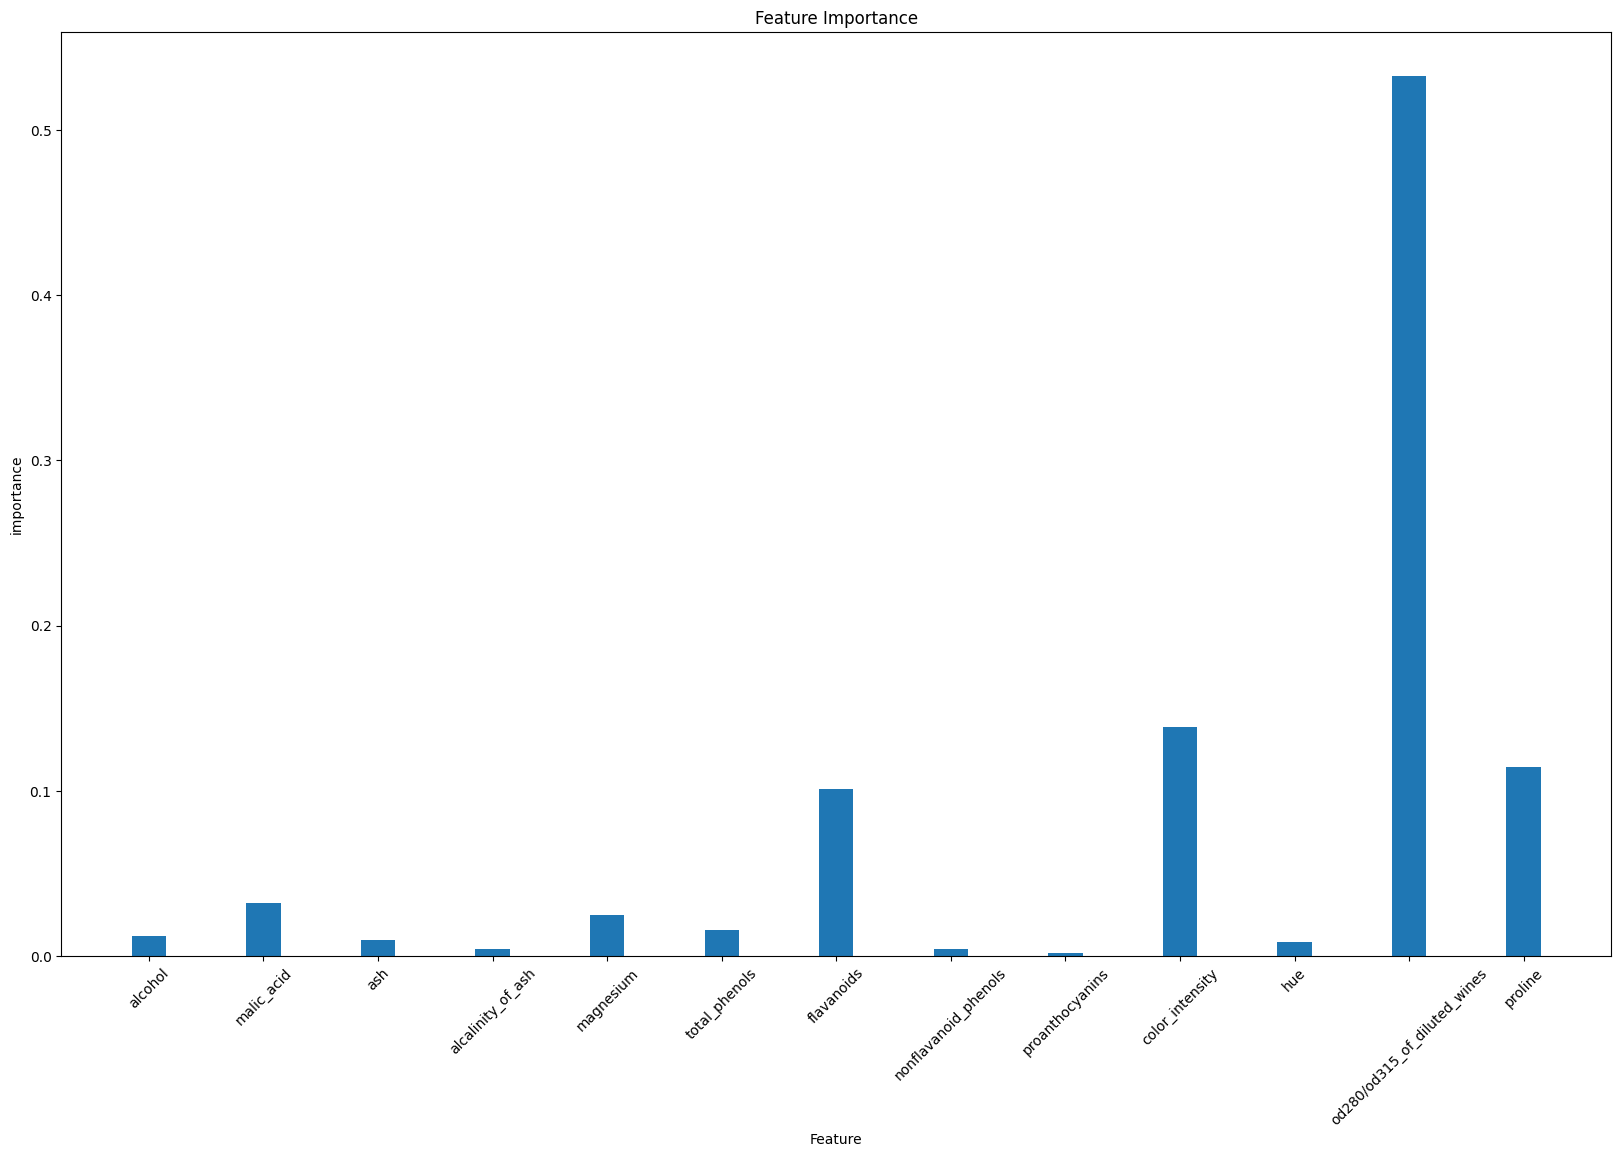

In [5]:
''' 코드를 작성해주세요 '''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance, plot_tree

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score

# 학습데이터 구성 및 전처리
from sklearn.preprocessing import LabelEncoder, StandardScaler


# 레이블링 인코딩
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# XGboost 모델 생성 및 학습
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train_encoded)


# 예측 및 레이블 디코딩
xgb_y_pred_encoded = xgb_model.predict(X_test)

# 하이퍼파라미터 범위지정
params = {
    "max_depth" : [3, 5, 7, 9, 15],
    "learning_rate" : [0.1, 0.01, 0.001],
    "n_estimators": [50, 100, 200, 300]
}

# 하이퍼파라미터 최적화 
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=params, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_xgb.fit(X_train, y_train_encoded)

# 최적의 하이퍼파라미터의 학습
best_params_xgb = grid_search_xgb.best_params_
best_model_xgb = grid_search_xgb.best_estimator_

#테스트 데이터에 대한 예측
y_pred_encoded = best_model_xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test_encoded, y_pred_encoded)

print(f"Best Hyper-parmeter {best_params_xgb}")
print(f"Best Score {accuracy_xgb}")

# Feature Importance 시각화
importances = best_model_xgb.feature_importances_

plt.figure(figsize= (20,12))
#막대그래프 생성
plt.bar(range(len(importances)), importances, width= 0.3)
plt.xlabel('Feature')
plt.ylabel('importance')
plt.title('Feature Importance')
plt.xticks(range(len(importances)), X.columns, rotation =45)
plt.show()

<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

# 성능 비교 시각화

==================== DT 성능 확인 ====================
XGB accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

==================== XGB 성능 확인 ====================
XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



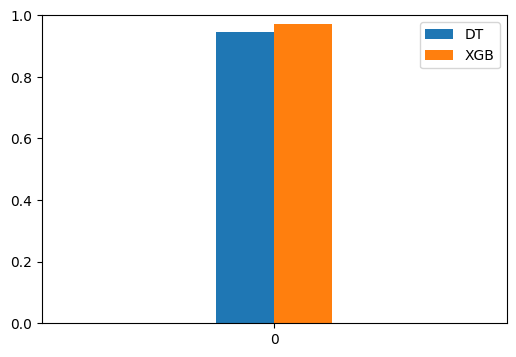

In [ ]:
''' 코드를 작성해주세요 '''
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

#테스트 데이터에 대한 예측
print("="*20,"DT 성능 확인", "="*20 )

print(f"XGB accuracy : {accuracy_grid}" )
print(classification_report(y_test, y_pred_grid))


print("="*20,"XGB 성능 확인", "="*20 )
y_pred_encoded = best_model.predict(X_test)
y_pred_xbg = label_encoder.inverse_transform(y_pred_encoded)

print(f"XGB accuracy : {accuracy_xgb}" )
print(classification_report(y_test, y_pred_xbg))

# 모델별 정확도 데이터
accuracy_scores = [accuracy_grid, accuracy_xgb]
models = ["DT", "XGB"]

# x축 위치 설정
x_pos = np.array([0])  # X 축 0을 기준
bar_width = 0.05  # 막대 너비 줄이기

# 그래프 크기 설정
plt.figure(figsize=(6, 4))

# DT (왼쪽으로 배치)
plt.bar(x_pos - bar_width/2, accuracy_scores[0], width=bar_width, color="#1f77b4", label="DT")

# XGB (오른쪽으로 배치)
plt.bar(x_pos + bar_width/2, accuracy_scores[1], width=bar_width, color="#ff7f0e", label="XGB")

# x축을 '0'으로 설정
plt.xticks([0], ["0"])
plt.ylim(0, 1)  # y축 범위 설정

# x축 간격을 넓혀 상대적으로 막대가 얇아 보이게 함
plt.xlim(-0.2, 0.2)

# 범례 추가
plt.legend(loc="upper right")

# 그래프 출력
plt.show()


<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">